In [ ]:
#We need a multivariate time series dataset, such as macroeconomic indicators, stock prices, or financial data.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

# Load dataset (example: macroeconomic data)
ice_cream_heater_df = pd.read_csv('ice_cream_vs_heater.xls')


In [39]:
ice_cream_heater_df.head()

,Month,heater,ice cream
0,2004-01,27,13
1,2004-02,18,15
2,2004-03,14,16
3,2004-04,13,19
4,2004-05,13,21


In [40]:
# Convert column year in datetime format
ice_cream_heater_df['Month'] = pd.to_datetime(ice_cream_heater_df['Month'])
ice_cream_heater_df = ice_cream_heater_df.set_index('Month')

In [41]:
ice_cream_heater_df.head()

,heater,ice cream
Month,,
2004-01-01,27,13
2004-02-01,18,15
2004-03-01,14,16
2004-04-01,13,19
2004-05-01,13,21


In [ ]:
#VAR models require stationary data, so we check for stationarity using the Augmented Dickey-Fuller (ADF) test.

In [42]:
from statsmodels.tsa.stattools import adfuller
##ADF TEST
#Null Hypothesis (HO): Series is non-stationary, or series has a unit root.
#Alternate Hypothesis(HA): Series is stationary, or series has no unit root.
#p-value < 0.05 – Reject Null Hypothesis(HO)

In [43]:
# Check for stationarity
def adf_test(series):
    result = adfuller(series)
    return result[1]  # p-value

In [44]:
adf_test(ice_cream_heater_df['heater'])

0.9937106551805233

In [45]:
adf_test(ice_cream_heater_df['ice cream'])

0.9249454712517602

In [10]:
#all are not stationary

In [46]:
# Differencing if necessary
df_diff = ice_cream_heater_df.diff().dropna()  # First-order differencing

In [47]:
adf_test(df_diff['heater'])

9.213801624030838e-30

In [48]:
adf_test(df_diff['ice cream'])

5.8938870173648073e-05

In [49]:
#Choosing the correct lag length (p) is crucial. We use Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC). 
#In a Vector Autoregressive (VAR) model, a lag refers to the number of past observations used to predict the current values of the time series variables.

In [55]:
# Select optimal lag length
model = VAR(ice_cream_heater_df)
lag_selection = model.select_order(maxlags=20)
optimal_lag = lag_selection.aic  # Using AIC-selected lag

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [51]:
print(lag_selection.summary()) 

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        10.32       10.36   3.039e+04       10.34
1        7.673       7.785       2150.       7.719
2        7.073       7.259       1180.       7.149
3        6.656       6.917       777.7       6.762
4        6.291       6.626       539.7       6.427
5        6.083       6.492       438.6       6.249
6        5.851      6.334*       347.7       6.047
7        5.828       6.385       339.9       6.054
8        5.864       6.497       352.8       6.121
9        5.748       6.455       314.2       6.035
10       5.683       6.464       294.5       6.000
11       5.657       6.513       287.4       6.005
12       5.514       6.444       249.2       5.891
13       5.479       6.483      241.0*      5.887*
14       5.509       6.588       248.7       5.947
15       5.530       6.683       254.3       5.998
16       5.556       6.783     

In [52]:
print(optimal_lag)

26


In [ ]:
#Once we have the optimal lag length, we fit the VAR model.

In [29]:
# Fit VAR model
var_model = VAR(ice_cream_heater_df)
results = var_model.fit(optimal_lag)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 24, Mar, 2025
Time:                     11:28:42
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                    6.27742
Nobs:                     185.000    HQIC:                   5.71838
Log likelihood:          -964.719    FPE:                    208.850
AIC:                      5.33742    Det(Omega_mle):         159.040
--------------------------------------------------------------------
Results for equation heater
                   coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------
const                 2.319106         1.515153            1.531           0.126
L1.heater             0.328029         0.079523            4.125           0.000
L1.ice cream         -0.017671         0.047492           -

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [16]:
#After fitting, ensure that the residuals (errors) are uncorrelated and normally distributed

In [30]:
# Check for autocorrelation in residuals (Ljung-Box test)
from statsmodels.stats.diagnostic import acorr_ljungbox

for col in results.resid.columns:
    print(f"\nLjung-Box Test for {col}:")
    lb_test = acorr_ljungbox(results.resid[col], lags=[10], return_df=True)
    print(lb_test)



Ljung-Box Test for heater:
     lb_stat  lb_pvalue
10  2.981241   0.981862

Ljung-Box Test for ice cream:
     lb_stat  lb_pvalue
10  2.152012   0.995037


In [ ]:
#If p-value > 0.05, residuals are white noise (good model fit).

In [31]:
# Forecast next 5 periods
forecast_steps = 5
forecast_values = results.forecast(ice_cream_heater_df.values[-optimal_lag:], steps=forecast_steps)

# Convert to DataFrame
forecast_df = pd.DataFrame(forecast_values, columns=ice_cream_heater_df.columns)
print(forecast_df)

      heater  ice cream
0  21.166264  78.100275
1  25.926839  58.037025
2  31.618888  45.546684
3  44.038844  40.968398
4  54.338738  39.310621


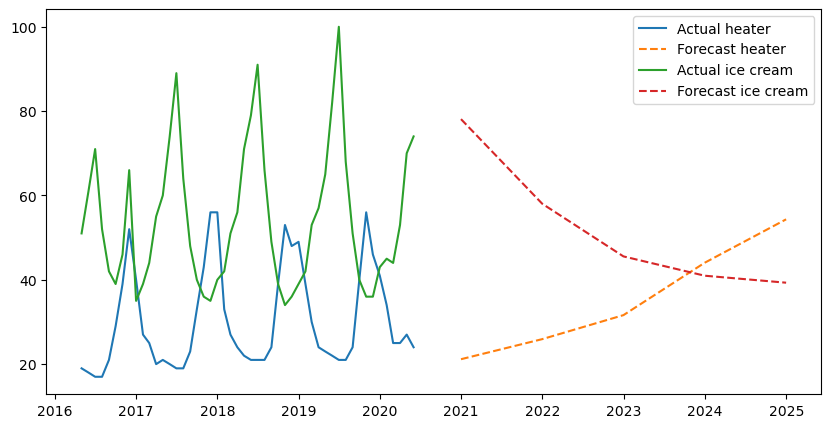

In [32]:
plt.figure(figsize=(10, 5))
for col in ice_cream_heater_df.columns:
    plt.plot(ice_cream_heater_df.index[-50:], ice_cream_heater_df[col].iloc[-50:], label=f'Actual {col}')
    plt.plot(pd.date_range(ice_cream_heater_df.index[-1], periods=forecast_steps, freq='Y'), forecast_df[col], linestyle='dashed', label=f'Forecast {col}')
plt.legend()
plt.show()

In [ ]:
#1️ Load and visualize the dataset.
#2 Check for stationarity (ADF test).
️#3 If needed, differencing to make data stationary.️
#4 Choose optimal lag length using AIC/BIC.️
#5 Fit the VAR model.️
#6 Perform residual diagnostics.
️#7 Forecast future values.
️#8 Plot the forecast vs actual.